![display relevant image here](path/url/to/image)
- Banner/header image

# Title
- Relevant to Data and Business Context

## Overview
- BLUF (Bottom Line Up Front)
- One paragraph summary of findings and analysis
- Frame your 'story'

## Business Understanding
- Set the stage for analysis
- Why are these findings relevant/important?
- Introduce stakeholders
- Postulate about questions you want to ask/answer

## Data Understanding
- Present the source of data
- Describe the data available
- What is relevant to keep what is not
- Present any data cleaning that needs to happen
- Null values? Type mismatches? Duplicates?

In [1]:
# Imports
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import (StructType, StructField, StringType, DoubleType)
from pyspark.sql.window import Window

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
# EDA Code Here - Create New Cells As Needed
# LOAD DATASET
import shutil
import glob
if shutil.which('java') is None:
    jdk_candidates = glob.glob(r'C:\Program Files\Eclipse Adoptium\jdk-*')
    if jdk_candidates:
        os.environ['JAVA_HOME'] = jdk_candidates[0]
        os.environ['PATH'] = os.path.join(jdk_candidates[0], 'bin') + os.pathsep + os.environ['PATH']
        print(f"JAVA_HOME set to {os.environ['JAVA_HOME']}")
    else:
        print("WARNING: Java not found on PATH. Install a JDK (e.g. Temurin 17) to run PySpark.")

try:
    spark = SparkSession.builder \
        .appName("GooglePlayStoreAnalysis") \
        .getOrCreate()
except Exception as e:
    print("Failed to create SparkSession. Ensure PySpark and Java are installed.")
    raise e

# Schema 
schema = StructType([
    StructField("App", StringType(), True),
    StructField("Category", StringType(), True),
    StructField("Rating", DoubleType(), True),
    StructField("Reviews", StringType(), True),
    StructField("Size", StringType(), True),
    StructField("Installs", StringType(), True),
    StructField("Type", StringType(), True),
    StructField("Price", StringType(), True),
    StructField("Content Rating", StringType(), True),
    StructField("Genres", StringType(), True),
    StructField("Last Updated", StringType(), True),
    StructField("Current Ver", StringType(), True),
    StructField("Android Ver", StringType(), True)
])

df = spark.read.csv('google_play_store_dataset.csv', header=True, schema=schema)

print(f"Dataset shape: {df.count()} rows, {len(df.columns)} columns")
print("First 5 rows:")
df.show(5, truncate=False)

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\testing\utils.py:127: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


Dataset shape: 10841 rows, 13 columns
First 5 rows:
+--------------------------------------------------+--------------+------+-------+----+-----------+----+-----+--------------+-------------------------+----------------+------------------+------------+
|App                                               |Category      |Rating|Reviews|Size|Installs   |Type|Price|Content Rating|Genres                   |Last Updated    |Current Ver       |Android Ver |
+--------------------------------------------------+--------------+------+-------+----+-----------+----+-----+--------------+-------------------------+----------------+------------------+------------+
|Photo Editor & Candy Camera & Grid & ScrapBook    |ART_AND_DESIGN|4.1   |159    |19M |10,000+    |Free|0    |Everyone      |Art & Design             |January 7, 2018 |1.0.0             |4.0.3 and up|
|Coloring book moana                               |ART_AND_DESIGN|3.9   |967    |14M |500,000+   |Free|0    |Everyone      |Art & Design;Preten

In [3]:
# Information and missing values
print("\nData types:")
df.printSchema()

print("\nMissing Values:")
missing_counts = {c: df.filter(F.col(c).isNull()).count() for c in df.columns}
for col, cnt in missing_counts.items():
    print(f"{col}: {cnt}")

print("\nStatistic's summary:")
df.describe().show()


Data types:
root
 |-- App: string (nullable = true)
 |-- Category: string (nullable = true)
 |-- Rating: double (nullable = true)
 |-- Reviews: string (nullable = true)
 |-- Size: string (nullable = true)
 |-- Installs: string (nullable = true)
 |-- Type: string (nullable = true)
 |-- Price: string (nullable = true)
 |-- Content Rating: string (nullable = true)
 |-- Genres: string (nullable = true)
 |-- Last Updated: string (nullable = true)
 |-- Current Ver: string (nullable = true)
 |-- Android Ver: string (nullable = true)


Missing Values:
App: 0
Category: 0
Rating: 2
Reviews: 0
Size: 0
Installs: 0
Type: 0
Price: 0
Content Rating: 1
Genres: 0
Last Updated: 0
Current Ver: 1
Android Ver: 1

Statistic's summary:
+-------+--------------------+-------------+------+-----------------+------------------+------------------+-----+------------------+--------------+------+-----------------+-------------+------------------+
|summary|                 App|     Category|Rating|          Reviews| 

## Data Preparation



In [4]:
# Data Prep Code Here

# Data Cleaning
df_clean = df

# Drop rows where Installs == 'Free'
df_clean = df_clean.filter(F.col('Installs') != 'Free')

# 1. Missing Ratings
df_clean = df_clean.filter(F.col('Rating').isNotNull() & ~F.isnan(F.col('Rating')))

# 2. Installs
df_clean = df_clean.withColumn(
    'Installs',
    F.when(
        (F.trim(F.col('Installs')) == 'Free') | (F.trim(F.col('Installs')) == ''),
        F.lit(None).cast('long')
    ).otherwise(
        F.regexp_replace(F.regexp_replace(F.trim(F.col('Installs')), ',', ''), r'\+', '').cast('long')
    )
)

# 3. Price
df_clean = df_clean.withColumn(
    'Price',
    F.regexp_replace(F.trim(F.col('Price')), r'\$', '').cast('double')
)

# 4. Reviews
df_clean = df_clean.withColumn(
    'Reviews',
    F.when(
        F.trim(F.col('Reviews')).endswith('M'),
        (F.regexp_replace(F.trim(F.col('Reviews')), 'M$', '').cast('double') * 1000000).cast('long')
    ).otherwise(
        F.regexp_replace(F.trim(F.col('Reviews')), ',', '').cast('long')
    )
)

# 5. Size
df_clean = df_clean.withColumn(
    'Size_MB',
    F.when(
        F.trim(F.col('Size')) == 'Varies with device',
        F.lit(None).cast('double')
    ).otherwise(
        F.when(
            F.lower(F.col('Size')).contains('k'),
            F.regexp_replace(F.col('Size'), r'[^0-9.]', '').cast('double') / 1024
        ).otherwise(
            F.regexp_replace(F.col('Size'), r'[^0-9.]', '').cast('double')
        )
    )
)

# 6. Genre
df_clean = df_clean.withColumn('Primary_Genre', F.split(F.col('Genres'), ';').getItem(0))

# 7. Last Updated
df_clean = df_clean.withColumn(
    'Last Updated',
    F.to_timestamp(F.col('Last Updated'), 'MMMM d, yyyy')
)

# 8. Dropping columns I won't use for analysis
df_clean = df_clean.drop('Size', 'Genres', 'Current Ver', 'Android Ver')

# Check cleaned data
print("Cleaned data shape:", df_clean.count(), "rows,", len(df_clean.columns), "columns")
print("\nMissing values after cleaning:")
missing_counts = {c: df_clean.filter(F.col(c).isNull()).count() for c in df_clean.columns}
for col, cnt in missing_counts.items():
    print(f"{col}: {cnt}")
print("\nCleaned data preview:")
df_clean.show(5, truncate=False)

Cleaned data shape: 9364 rows, 11 columns

Missing values after cleaning:
App: 0
Category: 0
Rating: 0
Reviews: 0
Installs: 0
Type: 0
Price: 0
Content Rating: 0
Last Updated: 0
Size_MB: 1636
Primary_Genre: 0

Cleaned data preview:
+--------------------------------------------------+--------------+------+-------+--------+----+-----+--------------+-------------------+-------+-------------+
|App                                               |Category      |Rating|Reviews|Installs|Type|Price|Content Rating|Last Updated       |Size_MB|Primary_Genre|
+--------------------------------------------------+--------------+------+-------+--------+----+-----+--------------+-------------------+-------+-------------+
|Photo Editor & Candy Camera & Grid & ScrapBook    |ART_AND_DESIGN|4.1   |159    |10000   |Free|0.0  |Everyone      |2018-01-07 00:00:00|19.0   |Art & Design |
|Coloring book moana                               |ART_AND_DESIGN|3.9   |967    |500000  |Free|0.0  |Everyone      |2018-01-15 0

In [5]:
# Saving cleaned data file for Tableau usage
df_clean.toPandas().to_csv('google_play_store_dataset_cleaned.csv', index=False)

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()
d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\types.py:778: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


## Data Analysis

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


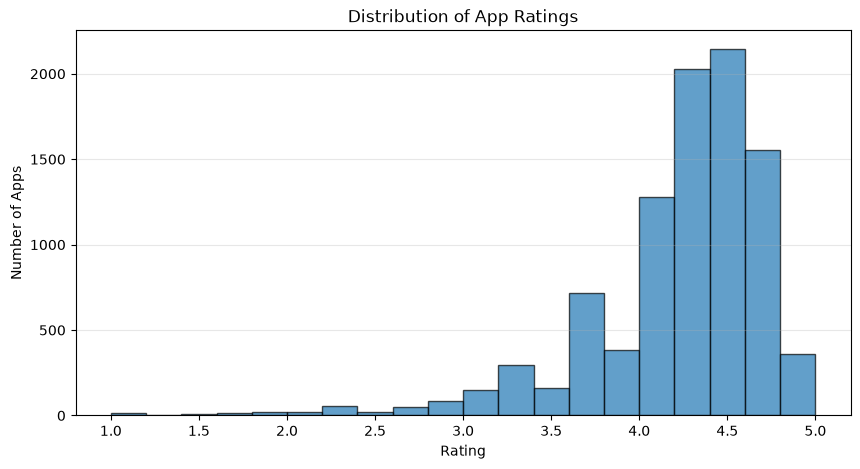

In [6]:
# Rating Distribution
ratings_pd = df_clean.select('Rating').toPandas()

plt.figure(figsize=(10,5))
plt.hist(ratings_pd['Rating'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [7]:
# Top 10 categories by avg rating
category_stats = df_clean.groupBy('Category').agg(
    F.avg('Rating').alias('Avg_Rating'),
    F.count('Rating').alias('Count'),
    F.percentile_approx('Installs', 0.5).alias('Median_Installs')
)

top_categories = category_stats \
    .filter(F.col('Count') >= 10) \
    .orderBy(F.col('Avg_Rating').desc()) \
    .limit(10)

top_categories.toPandas()

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,Category,Avg_Rating,Count,Median_Installs
0,EVENTS,4.44,45,50000
1,EDUCATION,4.39,155,1000000
2,ART_AND_DESIGN,4.36,62,100000
3,BOOKS_AND_REFERENCE,4.35,178,100000
4,PERSONALIZATION,4.34,314,100000
5,PARENTING,4.30,50,100000
6,GAME,4.29,1097,5000000
7,BEAUTY,4.28,42,100000
8,HEALTH_AND_FITNESS,4.28,296,1000000
9,SHOPPING,4.26,238,1000000


d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


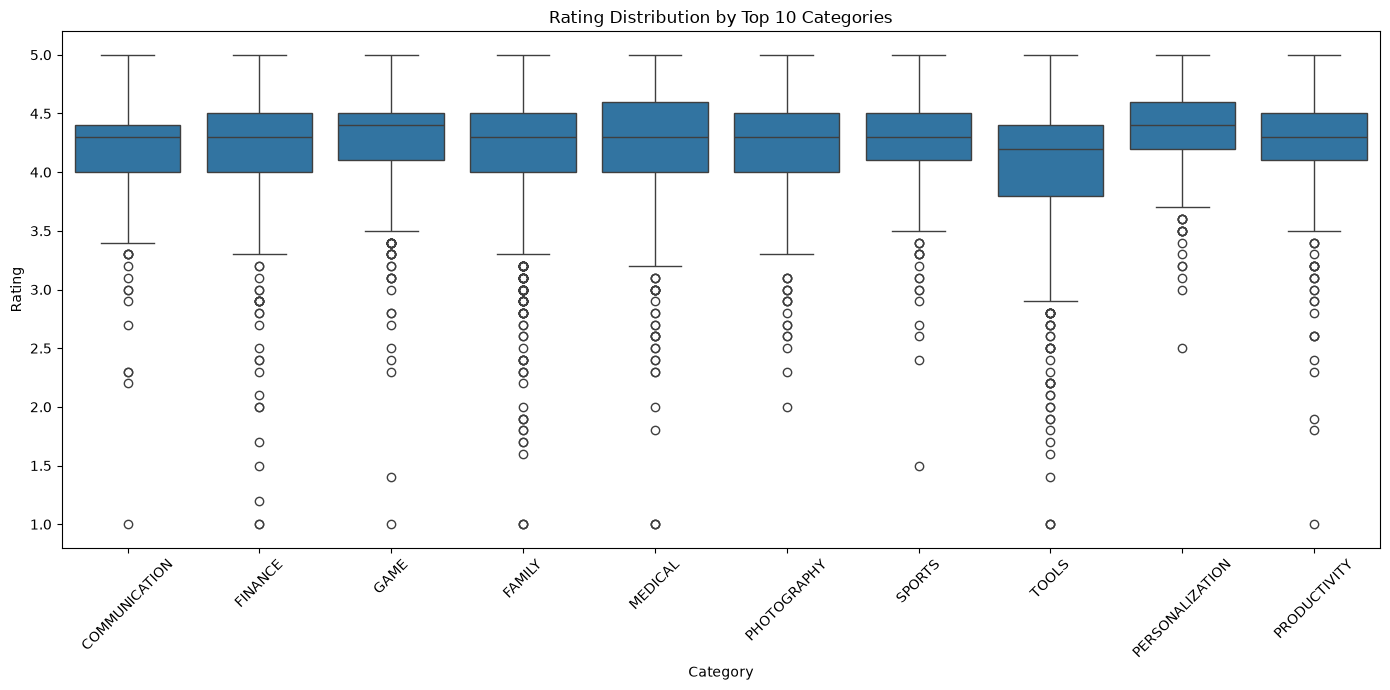

In [8]:
# Boxplot: Rating top 10 categories by count
top_cats = [row['Category'] for row in df_clean.groupBy('Category').count().orderBy(F.col('count').desc()).limit(10).collect()]
df_top = df_clean.filter(F.col('Category').isin(top_cats))

df_top_pd = df_top.select('Category', 'Rating').toPandas()

plt.figure(figsize=(14,7))
sns.boxplot(data=df_top_pd, x='Category', y='Rating')
plt.xticks(rotation=45)
plt.title('Rating Distribution by Top 10 Categories')
plt.tight_layout()
plt.show()

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


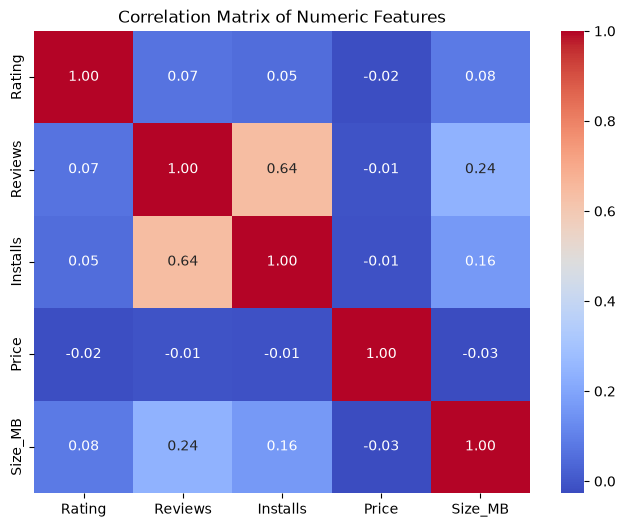

In [9]:
# Correlation heatmap
numeric_cols = ['Rating', 'Reviews', 'Installs', 'Price', 'Size_MB']
corr_pd = df_clean.select(numeric_cols).toPandas().corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr_pd, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix of Numeric Features')
plt.show()

In [10]:
# Free vs Paid: Avg Rating & Installs
df_clean.groupBy('Type').agg(
    F.avg('Rating').alias('Avg_Rating'),
    F.percentile_approx('Installs', 0.5).alias('Median_Installs'),
    F.count('App').alias('Count')
).toPandas()

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,Type,Avg_Rating,Median_Installs,Count
0,Free,4.19,1000000,8717
1,Paid,4.27,5000,647


In [11]:
# Top 10 most installed apps
df_clean.orderBy(F.col('Installs').desc()).limit(10) \
    .select('App', 'Category', 'Rating', 'Installs', 'Type', 'Price') \
    .toPandas()

d:\Anaconda3\envs\python3146\Lib\site-packages\pyspark\sql\pandas\conversion.py:298: FutureWarning: PySpark does not yet fully support pandas >= 3.0.0. Some features may not work correctly. It is recommended to use pandas < 3.0.0 for now.
  require_minimum_pandas_version()


,App,Category,Rating,Installs,Type,Price
0,Hangouts,COMMUNICATION,4.00,1000000000,Free,0.00
1,Google Chrome: Fast & Secure,COMMUNICATION,4.30,1000000000,Free,0.00
2,Google Play Books,BOOKS_AND_REFERENCE,3.90,1000000000,Free,0.00
3,WhatsApp Messenger,COMMUNICATION,4.40,1000000000,Free,0.00
4,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,1000000000,Free,0.00
5,Messenger – Text and Video Chat for Free,COMMUNICATION,4.00,1000000000,Free,0.00
6,Gmail,COMMUNICATION,4.30,1000000000,Free,0.00
7,Hangouts,COMMUNICATION,4.00,1000000000,Free,0.00
8,Google Chrome: Fast & Secure,COMMUNICATION,4.30,1000000000,Free,0.00
9,Skype - free IM & video calls,COMMUNICATION,4.10,1000000000,Free,0.00


In [12]:
# Window Function 
window_spec = Window.partitionBy('Category').orderBy(F.col('Installs').desc())

ranked = df_clean.withColumn('Rank_In_Category', F.row_number().over(window_spec))

# Top 3 most-installed apps in each category.
ranked.filter(F.col('Rank_In_Category') <= 3) \
    .select('Category', 'App', 'Installs', 'Rank_In_Category') \
    .orderBy('Category', 'Rank_In_Category') \
    .show(30, truncate=False)

+-------------------+-------------------------------------------------------+----------+----------------+
|Category           |App                                                    |Installs  |Rank_In_Category|
+-------------------+-------------------------------------------------------+----------+----------------+
|ART_AND_DESIGN     |Sketch - Draw & Paint                                  |50000000  |1               |
|ART_AND_DESIGN     |Tattoo Name On My Photo Editor                         |10000000  |2               |
|ART_AND_DESIGN     |ibis Paint X                                           |10000000  |3               |
|AUTO_AND_VEHICLES  |Android Auto - Maps, Media, Messaging & Voice          |10000000  |1               |
|AUTO_AND_VEHICLES  |AutoScout24 - used car finder                          |10000000  |2               |
|AUTO_AND_VEHICLES  |Ulysse Speedometer                                     |5000000   |3               |
|BEAUTY             |Beauty Camera - Selfie Ca

## Conclusion

Markdown here

The **average rating** for apps on the Play Store is about 4.2, with most apps falling between 4.0 and 4.5. Art & Design apps have high ratings but relatively fewer installs compared to Games and Social apps. Free apps outnumber paid apps and have higher median installs, though paid apps tend to have slightly higher average ratings. There is a weak positive correlation between number of reviews and installs—more popular apps get more reviews—but rating shows virtually no correlation with app size or price.



**For developers**, free apps with in-app purchases are advisable: WHY? they drive downloads without heavily affecting the ratings. Marketers should prioritize categories with high user satisfaction like Art & Design or Education.



**For investors**, acquisition of apps with over 10 million installs and a rating above 4.5 are the strongest targets.



A few **limitations** apply to the findings: 

-Roughly 10% of ratings were missing and dropped, which may cause a slight bias in the results. 

-Some size entries were also listed as "Varies with device" and converted to missing values. 

-The dataset is from 2018, so recent trends may be different.